# Predicting High Audience Ratings for Silver Screen Studios

**Role:** Data scientist responding to a client proposal from Silver Screen Studios, a film studio deciding which projects to fund.

**The client's problem:** Silver Screen Studios wants to know, before a film is made, whether it is likely to be received exceptionally well by audiences. Concretely, they want a way to estimate whether a proposed film would reach an IMDb audience rating of 8.0 or higher, using only information that exists during pre-production, such as genre, runtime, certificate, and the people attached to the project. The goal is to support funding decisions: projects that look likely to cross the 8.0 threshold are stronger candidates for production funding. Anything that can only be measured after a film is released cannot be used as an input, since it would not be available at the moment the funding decision is made.

In [1]:
import pandas as pd

df = pd.read_csv("data/imdb_top_1000.csv")

print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)
df.head()

Shape: (1000, 16)

Dtypes:
Poster_Link       object
Series_Title      object
Released_Year     object
Certificate       object
Runtime           object
Genre             object
IMDB_Rating      float64
Overview          object
Meta_score       float64
Director          object
Star1             object
Star2             object
Star3             object
Star4             object
No_of_Votes        int64
Gross             object
dtype: object


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


## Column dictionary

| Column | Dtype as loaded | Description |
|---|---|---|
| Poster_Link | object | URL to the movie poster image on IMDb. |
| Series_Title | object | Title of the film. |
| Released_Year | object | Year the film was released. Loaded as text because at least one row contains a non-numeric value. |
| Certificate | object | Age certification the film received, such as A, UA, or PG-13. |
| Runtime | object | Length of the film as text, for example "142 min". |
| Genre | object | One or more genres as a comma-separated string, for example "Action, Crime, Drama". |
| IMDB_Rating | float64 | Average IMDb user rating on a 0 to 10 scale. This is the basis of the prediction target. |
| Overview | object | Short plot summary of the film. |
| Meta_score | float64 | Metacritic critic score on a 0 to 100 scale. |
| Director | object | Name of the film's director. |
| Star1 | object | First-billed cast member. |
| Star2 | object | Second-billed cast member. |
| Star3 | object | Third-billed cast member. |
| Star4 | object | Fourth-billed cast member. |
| No_of_Votes | int64 | Number of IMDb user votes behind the rating. |
| Gross | object | Box office gross in US dollars, loaded as text because the values contain commas. |

**Note on differences from the proposal.** The client's proposal listed only 10 columns and stated that cast information was not in the dataset. The file actually contains 16 columns, including Star1 through Star4, No_of_Votes, and Gross. Meta_score, No_of_Votes, and Gross are only known after a film is released, so under the pre-production framing they are excluded as model inputs. The cast columns (Star1 through Star4) are pre-production information in principle, but since the proposal said cast was unavailable, their use is pending clarification with the client.

## Exploratory data analysis

### Part 1: Data quality

**Runtime.** Runtime is stored as text such as "142 min". We strip the " min" suffix and convert to a numeric minutes column, `Runtime_Min`. Every row parses cleanly. Runtimes range from 45 to 321 minutes with a mean of about 123 minutes.

In [2]:
df["Runtime_Min"] = df["Runtime"].str.replace(" min", "").astype(int)
print(df["Runtime_Min"].describe().round(1))

count    1000.0
mean      122.9
std        28.1
min        45.0
25%       103.0
50%       119.0
75%       137.0
max       321.0
Name: Runtime_Min, dtype: float64


**Gross.** Gross is stored as text with thousands separators, such as "28,341,469". We remove the commas and convert to numeric. The conversion itself introduces no new gaps, but 169 films have no gross figure at all. We keep those rows, since Gross is post-release context rather than a model input, so its gaps do not need filling.

In [3]:
missing_before = df["Gross"].isna().sum()
df["Gross"] = pd.to_numeric(df["Gross"].str.replace(",", ""), errors="coerce")
print("Missing before conversion:", missing_before)
print("Missing after conversion: ", df["Gross"].isna().sum())

Missing before conversion: 169
Missing after conversion:  169


**Released_Year.** The year column loaded as text, which suggests at least one non-numeric value. Attempting a numeric conversion and inspecting the failures shows exactly one bad row: Apollo 13 has the value "PG", which looks like a data entry slip where the certificate landed in the wrong field. Apollo 13 was released in 1995, so we set the year by hand rather than dropping the row, then convert the whole column to integer.

In [4]:
year_numeric = pd.to_numeric(df["Released_Year"], errors="coerce")
print(df.loc[year_numeric.isna(), ["Series_Title", "Released_Year", "Director"]])

df.loc[df["Series_Title"] == "Apollo 13", "Released_Year"] = 1995
df["Released_Year"] = df["Released_Year"].astype(int)
print("\nYear range:", df["Released_Year"].min(), "to", df["Released_Year"].max())

    Series_Title Released_Year    Director
966    Apollo 13            PG  Ron Howard

Year range: 1920 to 2020


**Certificate and Meta_score.** Certificate is missing for 101 films and Meta_score for 157. We leave both as they are. Certificate can be encoded with an explicit "Missing" category when we build features, and Meta_score is a post-release column that will not be a model input, so its gaps do not affect modeling.

In [5]:
print("Missing Certificate:", df["Certificate"].isna().sum())
print("Missing Meta_score: ", df["Meta_score"].isna().sum())

Missing Certificate: 101
Missing Meta_score:  157


**Genre.** Each film lists one to three genres in a single comma-separated string, so genre counts require splitting the column first. After splitting there are 21 distinct genres. Drama dominates, appearing on 724 of the 1000 films, followed by Comedy (233) and Crime (209). Because one film can carry several genres, the counts below sum to more than 1000, and this column will need exploding or multi-label encoding before it can be used as a feature.

In [6]:
genre_counts = df["Genre"].str.split(", ").explode().value_counts()
print("Distinct genres:", genre_counts.size)
print(genre_counts)

Distinct genres: 21
Genre
Drama        724
Comedy       233
Crime        209
Adventure    196
Action       189
Thriller     137
Romance      125
Biography    109
Mystery       99
Animation     82
Sci-Fi        67
Fantasy       66
History       56
Family        56
War           51
Music         35
Horror        32
Western       20
Film-Noir     19
Sport         19
Musical       17
Name: count, dtype: int64


### Part 2: Distributions and relationships

**Target variable.** The target is `high_rated`, True when IMDB_Rating is at least 8.0. The split is 463 high rated films (46.3 percent) against 537 below the threshold (53.7 percent). This is close to balanced, so the mild imbalance needs no resampling or class weighting. Accuracy alone is a weak summary, so later evaluation should also report precision and recall.

In [7]:
df["high_rated"] = df["IMDB_Rating"] >= 8.0
counts = df["high_rated"].value_counts()
print(pd.DataFrame({"count": counts, "percent": (100 * counts / len(df)).round(1)}))

            count  percent
high_rated                
False         537     53.7
True          463     46.3


**Distribution of IMDb ratings.** The histogram below shows the most important fact about this dataset: ratings start around 7.6, because this is the IMDb top 1000 and it contains no poorly received films. Any model trained on it can only learn to separate well received films from exceptionally well received ones. It cannot tell a hit from a flop, and applying it to a typical unreleased project is an extrapolation beyond the data.

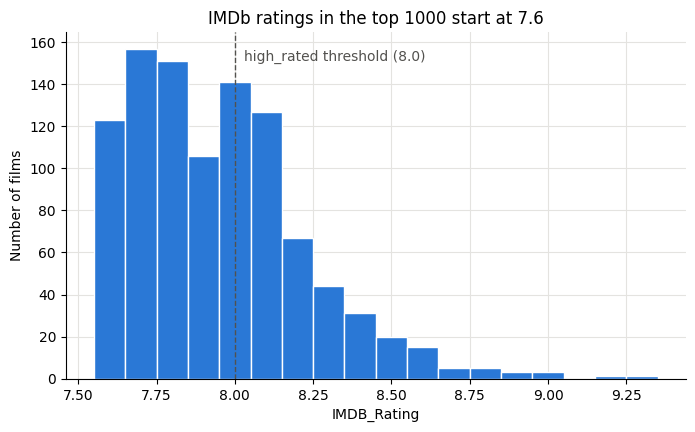

In [8]:
import numpy as np
import matplotlib.pyplot as plt

BLUE = "#2a78d6"
INK = "#52514e"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e4e3e0", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "figure.dpi": 100,
})

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df["IMDB_Rating"], bins=np.arange(7.55, 9.45, 0.1), color=BLUE, edgecolor="white")
ax.axvline(8.0, color=INK, linestyle="--", linewidth=1)
ax.text(8.03, ax.get_ylim()[1] * 0.95, "high_rated threshold (8.0)", color=INK, va="top")
ax.set_title("IMDb ratings in the top 1000 start at 7.6")
ax.set_xlabel("IMDB_Rating")
ax.set_ylabel("Number of films")
plt.show()

**Rating vs runtime.** A scatter of rating against runtime in minutes. There is a weak positive relationship (correlation about 0.24): longer films rate slightly higher on average, but the vertical spread at any runtime is wide, so runtime on its own separates the classes only a little.

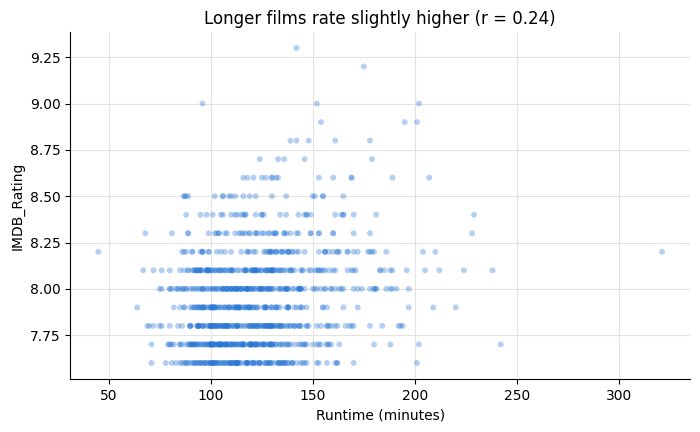

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(df["Runtime_Min"], df["IMDB_Rating"], s=18, alpha=0.35, color=BLUE, edgecolors="none")
ax.set_title(f"Longer films rate slightly higher (r = {df['Runtime_Min'].corr(df['IMDB_Rating']):.2f})")
ax.set_xlabel("Runtime (minutes)")
ax.set_ylabel("IMDB_Rating")
plt.show()

**Rating over time.** Mean rating per release decade. The line is nearly flat, staying within roughly 7.9 to 8.1 across a century. Earlier decades sit slightly higher, which likely reflects survivorship: only the best remembered old films make a top 1000 list. The endpoints rest on few films (11 from the 1920s, 6 from the 2020s), so their means are noisy. Release year tells us little.

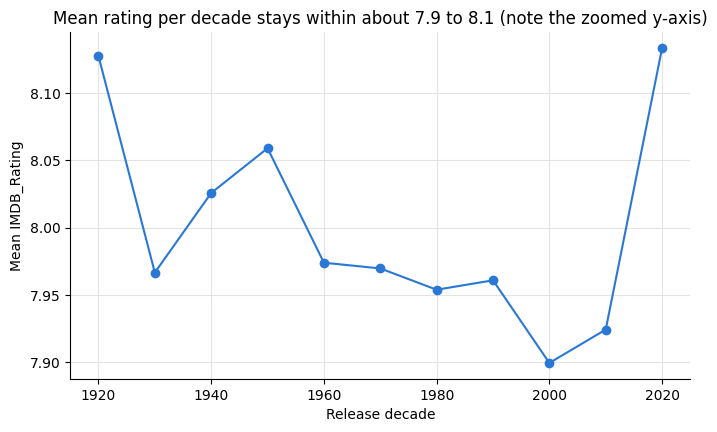

In [10]:
decade_stats = df.groupby(df["Released_Year"] // 10 * 10)["IMDB_Rating"].agg(["mean", "count"])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(decade_stats.index, decade_stats["mean"], marker="o", color=BLUE)
ax.set_title("Mean rating per decade stays within about 7.9 to 8.1 (note the zoomed y-axis)")
ax.set_xlabel("Release decade")
ax.set_ylabel("Mean IMDB_Rating")
plt.show()

**Rating by genre.** We explode the multi-label Genre column and compute the mean rating and film count per genre. The spread across genres is narrow, from about 7.89 for Horror to 8.01 for War. Genre shifts the average only slightly, and the category sizes differ enormously (Drama has 724 films, Film-Noir 19), so genre is also not too. helpful by itself, though it may still combine usefully with other features.

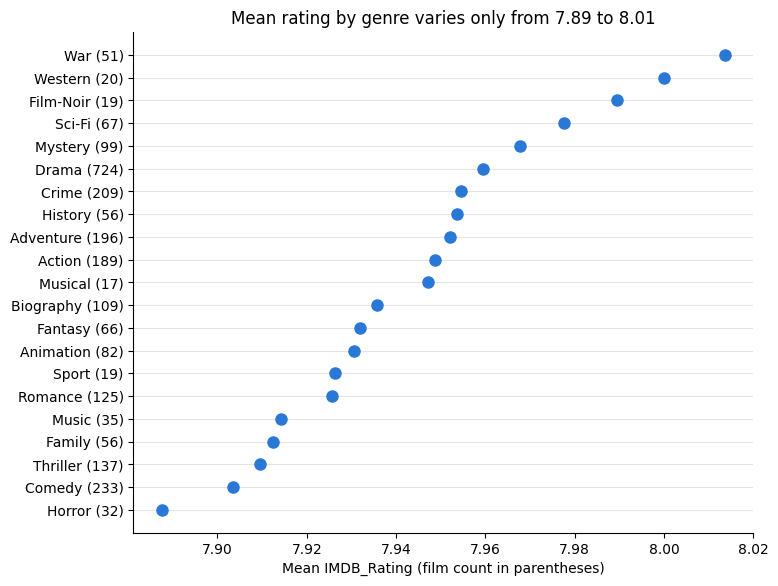

In [11]:
genre_stats = (df.assign(Genre=df["Genre"].str.split(", ")).explode("Genre")
               .groupby("Genre")["IMDB_Rating"].agg(["mean", "count"])
               .sort_values("mean"))
labels = [f"{g} ({c})" for g, c in zip(genre_stats.index, genre_stats["count"])]

fig, ax = plt.subplots(figsize=(8, 6.5))
ax.plot(genre_stats["mean"], range(len(genre_stats)), "o", color=BLUE, markersize=8)
ax.set_yticks(range(len(genre_stats)), labels)
ax.grid(axis="x")
ax.set_title("Mean rating by genre varies only from 7.89 to 8.01")
ax.set_xlabel("Mean IMDB_Rating (film count in parentheses)")
plt.show()

**Rating by certificate.** Mean rating per certificate, shown for certificates held by at least 10 films. Rarer certificates and the 101 missing values are left out of the chart only, not the data. Differences are again small, from about 7.80 for PG-13 up to 8.02 for Passed, so certificate is another weak standalone.

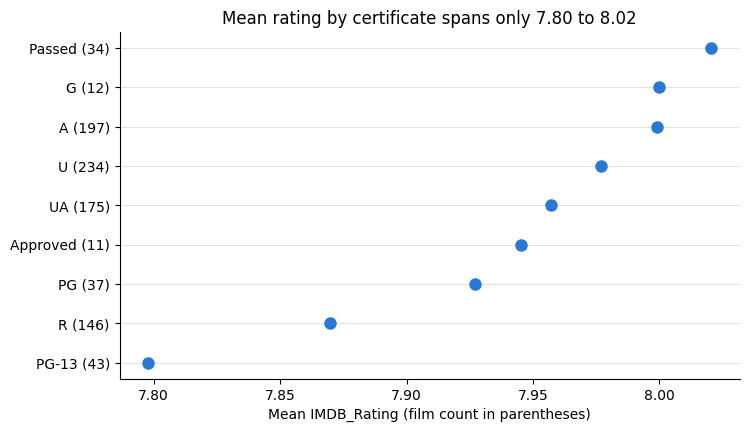

In [12]:
cert_stats = (df.groupby("Certificate")["IMDB_Rating"].agg(["mean", "count"])
              .query("count >= 10").sort_values("mean"))
labels = [f"{c} ({n})" for c, n in zip(cert_stats.index, cert_stats["count"])]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(cert_stats["mean"], range(len(cert_stats)), "o", color=BLUE, markersize=8)
ax.set_yticks(range(len(cert_stats)), labels)
ax.grid(axis="x")
ax.set_title("Mean rating by certificate spans only 7.80 to 8.02")
ax.set_xlabel("Mean IMDB_Rating (film count in parentheses)")
plt.show()

**Director frequency.** The 1000 films come from 548 different directors. 352 of them appear exactly once and 196 appear more than once; the most frequent is Alfred Hitchcock with 14 films. One-hot encoding it would create hundreds of columns that each match a single film. If director is used at all it needs aggregation, for example a repeat-director flag or a per-director film count.

Distinct directors: 548
Appear once:        352
Appear 2+ times:    196


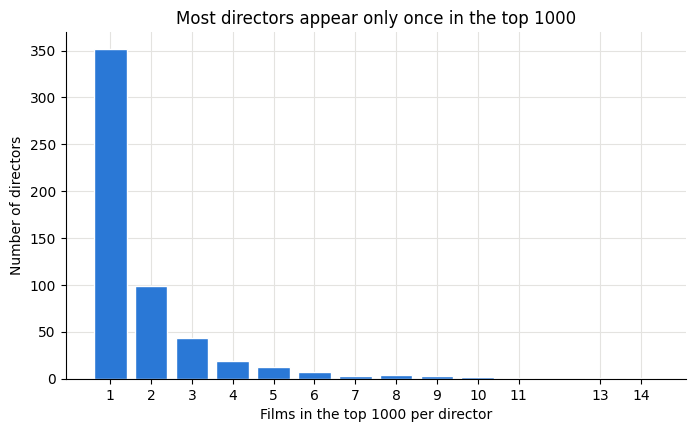

In [13]:
films_per_director = df["Director"].value_counts()
print("Distinct directors:", films_per_director.size)
print("Appear once:       ", (films_per_director == 1).sum())
print("Appear 2+ times:   ", (films_per_director > 1).sum())

dist = films_per_director.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(dist.index, dist.values, color=BLUE, edgecolor="white")
ax.set_xticks(dist.index)
ax.set_title("Most directors appear only once in the top 1000")
ax.set_xlabel("Films in the top 1000 per director")
ax.set_ylabel("Number of directors")
plt.show()

**Rating vs commercial performance.** The last two charts are context for the client, not feature exploration: Gross, No_of_Votes, and Meta_score are only known after release and stay excluded as model inputs. First, rating against box office gross on a log scale, for the 831 films with a gross figure. The correlation between rating and log gross is essentially zero. Within this top tier, how highly audiences rate a film says almost nothing about how much money it earns, so a high predicted rating should not be read as a revenue forecast.

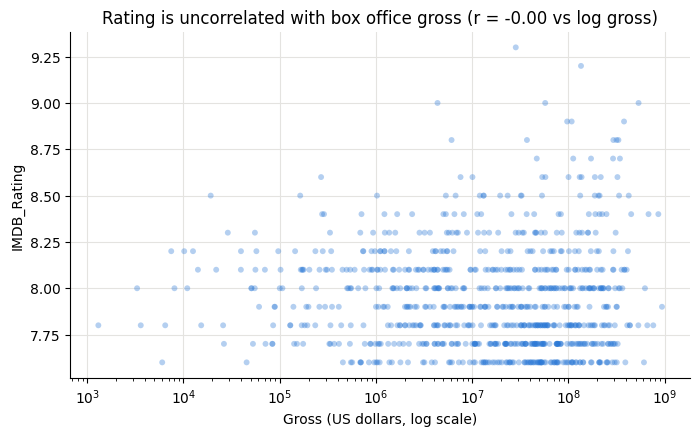

In [14]:
has_gross = df.dropna(subset=["Gross"])
r = np.corrcoef(np.log10(has_gross["Gross"]), has_gross["IMDB_Rating"])[0, 1]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(has_gross["Gross"], has_gross["IMDB_Rating"], s=18, alpha=0.35, color=BLUE, edgecolors="none")
ax.set_xscale("log")
ax.set_title(f"Rating is uncorrelated with box office gross (r = {r:.2f} vs log gross)")
ax.set_xlabel("Gross (US dollars, log scale)")
ax.set_ylabel("IMDB_Rating")
plt.show()

Second, rating against the number of IMDb votes, also on a log scale. Here the relationship is moderately positive (correlation about 0.33 with log votes): films with more votes tend to be rated somewhat higher. Part of this is a popularity feedback effect on IMDb itself, where widely seen films attract both votes and enthusiasm, so it should not be read as pure quality either.

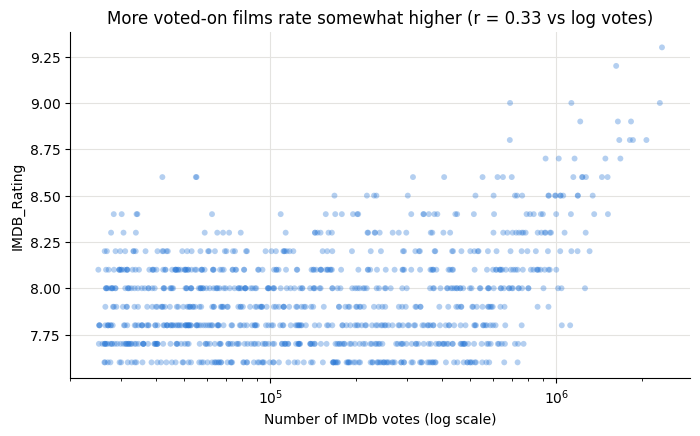

In [15]:
r = np.corrcoef(np.log10(df["No_of_Votes"]), df["IMDB_Rating"])[0, 1]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(df["No_of_Votes"], df["IMDB_Rating"], s=18, alpha=0.35, color=BLUE, edgecolors="none")
ax.set_xscale("log")
ax.set_title(f"More voted-on films rate somewhat higher (r = {r:.2f} vs log votes)")
ax.set_xlabel("Number of IMDb votes (log scale)")
ax.set_ylabel("IMDB_Rating")
plt.show()

### EDA summary

The data needed only light cleaning: Runtime and Gross were converted from text to numbers, one Released_Year typo (Apollo 13) was fixed by hand, and no rows were dropped. Missing values are confined to Gross (169), Meta_score (157), and Certificate (101), none of which blocks modeling. The target split of 46 to 54 is close to balanced. The defining limitation is selection: every film here is already among IMDb's best, with ratings from 7.6 up, so a model can only learn what separates well received films from exceptional ones, not hits from flops. Within that band the pre-production signals are individually weak: runtime correlates mildly with rating, genre and certificate move the mean by about a tenth of a point, and director is mostly singletons that would need aggregation to be usable. Commercial performance offers no shortcut either, since rating is essentially uncorrelated with gross in this data. The client should expect modest predictive performance and read the model as ranking projects within an already strong field.